# 2주차 (이론) — Python 기초: 값과 타입, 연산자, 제어문

## 학습 목표

이 주차를 마치면 다음을 할 수 있습니다.

1. 값의 **타입**을 구분하고 `type()`으로 확인하며, 필요할 때 **형변환**할 수 있다
2. **변수**를 만들고 파이썬의 명명 규칙과 참조(reference) 개념을 설명할 수 있다
3. **문자열**을 인덱싱·슬라이싱하고 주요 메서드를 사용할 수 있다
4. **f-string**으로 원하는 형식에 맞춰 값을 출력할 수 있다
5. **연산자**의 우선순위와 결합 방향을 근거로 식의 결과를 예측할 수 있다
6. **if / while / for**로 조건 분기와 반복을 작성할 수 있다


> `Shift + Enter`로 셀을 실행합니다.

In [ ]:
# 실행 환경 확인
import sys
print(sys.version)

---
## 1. 값과 타입 (Values and Types)

모든 데이터(값)는 **타입**을 가집니다.

- `str`(문자열), `int`(정수), `float`(실수), `bool`(참/거짓), `tuple`(튜플), ...

`type()`: 값이나 변수의 타입을 알려주는 내장 함수

- 인자로 넘어온 값/변수의 데이터 타입을 리턴
- 파이썬 변수는 **어떤 타입의 값이든 가리킬 수 있으므로**, 디버깅할 때 유용합니다

In [ ]:
print(type('Hello world!'))
print(type(17))
print(type(3.2))
print(type('17'))       # 따옴표가 있으므로 숫자가 아니라 문자열
print(type((1, 0, 0)))
print(type(True))

### 실수 타입에 대한 정확한 설명

파이썬의 실수 타입은 **`float` 하나뿐**입니다. C/Java처럼 `float`(32비트)와 `double`(64비트)로 나뉘지 않습니다.

단, 이름이 `float`일 뿐 **내부 표현은 C의 `double`과 동일한 64비트 배정밀도(double precision)** 입니다.
즉 "파이썬에는 double이 없다"가 아니라, **"파이썬의 float이 곧 double이다"** 가 정확한 표현입니다.

In [ ]:
import sys
print(sys.float_info.dig)       # 신뢰할 수 있는 10진 유효자리 수
print(sys.float_info.mant_dig)  # 가수(mantissa) 비트 수 → 53 = 배정밀도(double)

### 숫자에 콤마를 쓰면 안 되는 이유

파이썬에서 콤마는 값을 나열해 **튜플**을 만드는 기호입니다. 따라서 `1,000,000`은 백만이 아니라
`(1, 0, 0)`이라는 **3개 원소의 튜플**이 됩니다.

자리 구분이 필요하면 콤마 대신 **밑줄 `_`** 를 씁니다 (`1_000_000`).

In [ ]:
num1 = 1000000
print(num1, type(num1))

num2 = 1,000,000     # 콤마 → 튜플 (1, 0, 0)
print(num2, type(num2))

num3 = 1_000_000     # 밑줄은 자리 구분용으로 무시됨
print(num3, type(num3))

> **주의 (자주 나오는 함정)**
> `1,000,000`이 오류 없이 `(1, 0, 0)`이 되는 것은 **우연**입니다.
> `000`은 "0이 여러 개"라서 허용되지만, `1,012,000`처럼 **0이 아닌 숫자 앞에 0이 붙으면**
> `SyntaxError: leading zeros in decimal integer literals are not permitted` 오류가 납니다.
> 파이썬 3에서 `012`는 정수 리터럴로 쓸 수 없습니다 (8진법은 뒤에 나오는 `0o12` 표기를 씁니다).

In [ ]:
# 아래 주석을 풀면 SyntaxError가 납니다. 직접 확인해 보세요.
# num4 = 1,012,000

---
## 2. 숫자 (Numbers)

- **정수(int)**: `2`, `32`, `-32` — 파이썬의 정수는 자리수 제한이 없습니다
- **실수(float)**: `34.`, `3.23`, `52.3e-4` (`e-4`는 $\times 10^{-4}$)

### 자주 쓰는 내장 함수

| 식 | 값 | 식 | 값 | 식 | 값 |
|---|---|---|---|---|---|
| `abs(3)` | `3` | `int(2.7)` | `2` | `round(2.7)` | `3` |
| `abs(0)` | `0` | `int(3)` | `3` | `round(2.317, 2)` | `2.32` |
| `abs(-3)` | `3` | `int(-2.7)` | `-2` | `round(2.317, 1)` | `2.3` |

- `abs(x)`: 절댓값
- `int(x)`: **버림** (0 방향으로 소수점 이하를 잘라냄) — `int(-2.7)`이 `-3`이 아니라 `-2`인 이유
- `round(x, n)`: 소수점 `n`째 자리까지 **반올림** (`n` 생략 시 정수)

In [ ]:
print(abs(-7), abs(7))
print(int(2.9), int(-2.9))    # 버림: 0 방향으로 잘라냄
print(round(2.9))
print(round(3.14159, 2))
print(52.3e-4)
print(2 ** 100)               # 파이썬 정수는 자리수 제한이 없음

### 두 가지 함정: 은행원 반올림과 부동소수점 오차

**(1) `round()`는 우리가 배운 "5는 올림"이 아닙니다.**
파이썬은 IEEE 754 표준의 **은행원 반올림(banker's rounding)** 을 사용합니다.
정확히 `.5`인 경우 **가까운 짝수**로 맞춥니다. 따라서 `round(0.5)`는 `1`이 아니라 `0`입니다.

**(2) 실수는 2진법으로 저장되므로 10진 소수를 정확히 표현할 수 없습니다.**
`0.1 + 0.2 == 0.3`은 **False**입니다. 실수 비교에는 `==`를 쓰지 말고 오차 허용 비교를 씁니다.

In [ ]:
print(round(0.5), round(1.5), round(2.5), round(3.5))   # 0 2 2 4 ← 가까운 짝수로

print(0.1 + 0.2)
print(0.1 + 0.2 == 0.3)                 # False!

import math
print(math.isclose(0.1 + 0.2, 0.3))     # 실수 비교는 이렇게

### 형변환 (type conversion)

서로 다른 타입을 섞어 계산하거나 출력하려면 타입을 맞춰 주어야 합니다.
⇒ `int()`, `float()`, `str()`로 변환합니다.

In [ ]:
print(int("12"))
print(float("3.5"))
print(str(12) + "점")        # 숫자를 문자열과 이어 붙이려면 str() 필요
print(int(float("3.9")))     # 문자열 "3.9" → 실수 3.9 → 정수 3

In [ ]:
# 아래 주석을 풀고 실행해 보세요 → ValueError
# int("3.5")

print(int(float("3.5")))   # 올바른 방법: 두 단계로 변환

`int("3.5")`가 오류인 이유: `int()`는 **정수 형태의 문자열만** 받습니다.
소수점이 있는 문자열은 `int(float("3.5"))`처럼 **두 단계로** 변환해야 합니다.

### 진법 (number systems)

정수는 2진법, 8진법, 16진법으로도 표기할 수 있으며, 리터럴 앞에 접두어를 붙여서 표시

- `0b`: 2진법
- `0o`: 8진법
- `0x`: 16진법

반대로, 정수를 각 진법의 문자열로 바꾸려면 `bin()`, `oct()`, `hex()` 함수 사용

In [ ]:
# 진법 문자열 → 정수
print(0b1010, 0o17, 0xff)

# 정수 → 진법 문자열
print(bin(10))
print(oct(15))
print(hex(255))

---
## 3. 변수 (Variables)

- **변수**: 값을 저장해 두고 이름으로 다시 꺼내 쓸 수 있게 하는 장치
- 별도의 타입 선언 없이 **할당문(`=`)만으로** 변수를 만들어 바로 사용합니다
- `=`는 "같다"가 아니라 **"오른쪽 값을 왼쪽 이름에 붙인다"** 는 뜻입니다 (같다는 `==`)

In [ ]:
speed = 50           # 할당
timeElapsed = 14
distance = speed * timeElapsed
print(distance)

### 주석 (comment)

`#` 뒤부터 그 줄 끝까지는 **주석**으로, 파이썬이 실행하지 않습니다.
코드가 *무엇을* 하는지가 아니라 ***왜*** 그렇게 했는지를 적는 것이 좋은 주석입니다.

In [ ]:
# 이 줄 전체는 주석입니다
tax_rate = 0.1      # 부가세율 10% (2026년 기준)
price = 12000
print(round(price * (1 + tax_rate)))

### 명명 규칙 (naming rules)

- **대소문자를 구분**합니다 (`score`와 `Score`는 다른 변수)
- 첫 글자는 **문자 또는 밑줄 `_`**, 그 다음부터는 문자·숫자·`_` 사용 가능
- **숫자로 시작할 수 없고, 공백이나 `-`는 쓸 수 없습니다**
- 이름은 그 변수가 무엇을 의미하는지 알 수 있게 짓습니다 (`n` 보다 `student_count`)
- 관례: 변수·함수는 `snake_case`, 상수는 `UPPER_CASE` (PEP 8)

**잘못된 변수 이름의 예**

| 잘못된 이름 | 이유 |
|---|---|
| `2things` | 숫자로 시작 |
| `this is spaced out` | 공백 포함 |
| `my-name` | `-`는 뺄셈 연산자로 해석됨 |
| `class` | 파이썬 키워드 |

> **참고**: 파이썬 3는 유니코드 식별자를 허용하므로 `평균 = 3` 처럼 **한글 변수명도 문법적으로는 동작**합니다.
> 하지만 협업·호환성 문제로 실무에서는 쓰지 않으며, 이 수업에서도 영문 이름을 사용합니다.

### 파이썬 키워드 (예약어)

키워드는 파이썬 문법이 이미 사용하고 있는 이름이라 **변수명으로 쓸 수 없습니다**.
외울 필요는 없습니다. 아래처럼 **직접 확인하는 방법**을 익히는 것이 낫습니다.

In [ ]:
import keyword

print(len(keyword.kwlist))
print(keyword.kwlist)

# soft keyword: 문맥에 따라서만 키워드로 동작 (변수명으로는 사용 가능하지만 권장하지 않음)
print(keyword.softkwlist)

print(keyword.iskeyword('class'), keyword.iskeyword('score'))

파이썬 3.9+ 키워드 (총 35개)

| | | | | |
|---|---|---|---|---|
| `False` | `del` | `if` | `or` | `while` |
| `None` | `elif` | `import` | `pass` | `with` |
| `True` | `else` | `in` | `raise` | `yield` |
| `and` | `except` | `is` | `return` | |
| `as` | `finally` | `lambda` | `try` | |
| `assert` | `for` | `nonlocal` | `async` | |
| `break` | `from` | `not` | `await` | |
| `class` | `global` | | | |
| `continue` | | | | |
| `def` | | | | |

> **주의**: `print`와 `exec`는 **파이썬 2에서는 키워드였지만 파이썬 3에서는 일반 함수**입니다.
> 그래서 `print = 5`는 문법 오류가 아니라 그냥 실행됩니다 — 다만 `print()` 함수를 못 쓰게 되므로 절대 하지 마세요.
> 반대로 `True = 5`는 진짜 키워드라서 `SyntaxError`입니다.

In [ ]:
# 아래 두 줄의 주석을 각각 풀어 직접 확인해 보세요.

# True = 5              # SyntaxError: cannot assign to True  (진짜 키워드)

# print = 5             # 오류 없이 실행됨 (print는 키워드가 아니라 내장 함수 이름)
# print("hello")        # → TypeError: 'int' object is not callable
# del print             # 잘못 덮어쓴 내장 이름은 del로 되살릴 수 있습니다

import keyword
print(keyword.iskeyword('True'), keyword.iskeyword('print'))   # True False

### 메모리에서의 변수와 값

In [ ]:
n = 5
print(n)
n = 7
print(n)

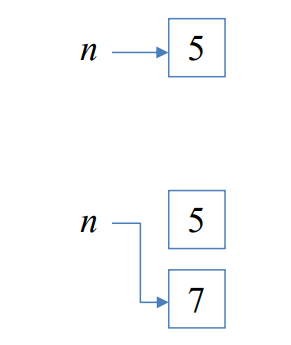

`n = 5`
메모리의 한 공간에 값 `5`가 만들어지고, 변수 `n`은 그 `5`를 **가리키도록(참조하도록)** 설정됩니다.

`n = 7`
값 `7`을 위한 **새로운** 메모리 공간이 마련되고, `n`은 기존의 `5`가 아니라 새 값 `7`을 가리키게 됩니다.
즉 파이썬의 변수는 **"값을 담는 상자"가 아니라 "값을 가리키는 이름표"** 입니다.

`5`는 더 이상 `n`의 참조를 받지 않으므로 참조를 잃은 상태(orphaned)가 되고,
파이썬은 이렇게 참조가 사라진 객체의 메모리를 자동으로 회수합니다 (수동 `free` 불필요).

> **참고 (정확한 동작)**
> CPython이 메모리를 회수하는 주 방법은 **참조 카운팅(reference counting)** 이며,
> `gc` 모듈의 가비지 컬렉터는 참조 카운팅이 해결하지 못하는 **순환 참조**를 담당합니다.
> 또한 CPython은 자주 쓰이는 **작은 정수(-5 ~ 256)를 미리 만들어 재사용**하므로,
> 위 예시의 `5`는 실제로는 회수되지 않고 인터프리터 내부에 계속 남아 있습니다.
> 그림은 **참조 개념**을 이해하기 위한 모델로 보면 됩니다.

In [ ]:
# id(): 객체의 고유 식별자(메모리 주소에 대응) 확인
n = 5
print(id(n))
n = 7
print(id(n))    # 다른 객체를 가리키게 되어 id가 바뀜

# 작은 정수 캐싱: 미리 만들어 둔 객체를 재사용하므로 두 변수가 같은 객체를 가리킴
# (int()로 만들어 컴파일러의 상수 최적화를 피한 뒤 비교)
a = 256
b = int("256")
print(id(a))
print(id(b))
print(a is b)   # True  ← -5 ~ 256 은 캐싱되어 재사용

c = 257
d = int("257")
print(id(c))
print(id(d))
print(c is d)   # False ← 캐싱 범위를 벗어나면 매번 새 객체

# 값이 같은지 볼 때는 is 가 아니라 == 를 써야 합니다
print(c == d)   # True

---
## 4. 문자열 (Strings)

- 작은따옴표 `'` 또는 큰따옴표 `"` 로 감싼 문자들의 나열
- 세 개짜리 따옴표(`'''` 또는 `"""`)로 **여러 줄 문자열**을 만들 수 있습니다
- 문자열은 **불변(immutable)**: 한 번 만든 문자열은 바꿀 수 없고, 바꾸려면 새 문자열을 만듭니다

In [ ]:
x = '''This is the first line.
This is the second line.
"What's your name?," I asked.
He said "Bond, James Bond."'''
print(x)

### 연결과 반복

In [ ]:
print('good' + 'bye')          # + : 연결(concatenation)
print(('a' + 'b') * 3)         # * : 반복
print('a' * 3 + 'b' * 3)
print(("cha-" * 2) + "cha")

### 길이, 인덱싱, 슬라이싱

- `len(s)`: 문자 개수
- **인덱싱** `s[i]`: `i`번째 문자 하나. 인덱스는 **0부터** 시작하고, 음수는 뒤에서부터 셉니다(`-1`이 마지막)
- **슬라이싱** `s[start:stop:step]`: `start`부터 `stop` **직전까지** 잘라낸 새 문자열
  - `start` 생략 → 처음부터, `stop` 생략 → 끝까지, `step`은 건너뛸 간격

```
 P  y  t  h  o  n
 0  1  2  3  4  5     ← 양수 인덱스
-6 -5 -4 -3 -2 -1     ← 음수 인덱스
```

In [ ]:
s = "Python"
print(len(s))

print(s[0], s[1], s[5])      # 인덱싱: 0부터 시작
print(s[-1], s[-2])          # 음수 인덱스: 뒤에서부터

print(s[0:3])                # 'Pyt'  ← 인덱스 3은 포함하지 않음
print(s[:3], s[3:])          # 앞부분 / 뒷부분
print(s[::2])                # 2칸씩 건너뛰기
print(s[::-1])               # 뒤집기 (자주 쓰는 관용구)

In [ ]:
# 인덱스를 벗어나면 오류, 슬라이싱은 오류가 나지 않습니다 — 차이를 확인해 보세요
s = "Python"
print(s[2:100])      # 오류 없이 잘라낼 수 있는 만큼만

# print(s[100])      # 주석을 풀면 IndexError

### 불변성(immutability) 확인

문자열의 일부만 바꾸려고 하면 오류가 납니다. 바꾸려면 **새 문자열을 만들어야** 합니다.

In [ ]:
s = "Python"

# s[0] = "J"      # 주석을 풀면 TypeError: 'str' object does not support item assignment

s2 = "J" + s[1:]  # 새 문자열을 만드는 것이 올바른 방법
print(s, s2)      # 원본 s는 그대로

### 문자열 메서드

`문자열.메서드()` 형태로 호출합니다.
문자열이 불변이므로 메서드는 **원본을 바꾸지 않고 새 문자열을 리턴**합니다.

In [ ]:
str1 = "Python"
print(str1.upper())         # 대문자로 변환
print(str1.lower())         # 소문자로 변환
print(str1.count('th'))     # 부분 문자열이 나온 횟수
print('coDE'.capitalize())  # 첫 문자만 대문자, 나머지는 소문자
print("beN hur".title())    # 각 단어의 첫 글자를 대문자로
print('     ab'.lstrip())   # 왼쪽 공백 제거
print('  ab  '.strip())     # 양쪽 공백 제거
print('a,b,c'.split(','))   # 구분자로 나누어 리스트로
print('-'.join(['a','b']))  # 리스트를 구분자로 이어 붙이기
print('Python'.replace('P', 'J'))
print(str1)                 # ← 원본은 전혀 변하지 않았음

In [ ]:
# 판별 메서드: 결과가 bool → 조건문에서 바로 쓸 수 있습니다
print("123".isdigit(), "12a".isdigit())
print("Python".startswith("Py"), "Python".endswith("on"))
print("th" in "Python")          # in 연산자로 포함 여부 확인
print("Python".find("th"))       # 위치(없으면 -1)

### 메서드 체이닝 (chained methods)

- 연결된 메서드는 **왼쪽에서 오른쪽 순서로** 실행됩니다
- 아래 `praise` 같은 **임시 변수를 없앨 수 있어** 코드가 더 간결해집니다

In [ ]:
praise = "Good Doggie".upper()      # 임시 변수 사용
numberOfGees = praise.count('G')
print(numberOfGees)

In [ ]:
numberOfGees = "Good Doggie".upper().count('G')   # 체이닝
print(numberOfGees)

### 이스케이프 시퀀스 (escape sequences)

역슬래시(`\`)로 시작하는 특수 표기입니다.

| 표기 | 의미 |
|---|---|
| `\n` | 줄바꿈 |
| `\t` | 탭 |
| `\'` `\"` | 따옴표 |
| `\\` | 역슬래시 |

문자열 앞에 `r`을 붙이면 이스케이프를 해석하지 않는 **raw 문자열**이 됩니다 (경로, 정규식에 유용).

In [ ]:
# 아래 주석을 풀면 SyntaxError — 문자열이 What 다음의 '에서 끝나 버립니다
# print('What's your name?')

In [ ]:
print("What's your name?")            # 큰따옴표로 감싸면 해결
print('What\'s your name?')           # 이스케이프로 해결
print('He said, "Bond, James Bond."')
print("He said, \"Bond, James Bond.\"")

In [ ]:
print("New lines are indicated by \n.")
print(r"New lines are indicated by \n.")   # raw 문자열
print("C:\temp\new")                       # \t, \n이 해석되어 깨짐
print(r"C:\temp\new")                      # 경로는 raw 문자열로

---
## 5. 출력과 포맷팅 (Output & Formatting)

### `print()`의 옵션

`print`는 여러 값을 출력할 때 공백으로 구분(`sep=' '`)하고, 끝에 줄바꿈(`end='\n'`)을 붙입니다.
이 기본값은 바꿀 수 있습니다.

In [ ]:
print("2026", "09", "01", sep="-")
print("a", "b", "c", sep="")

print("로딩중", end="")
print("...", end="")
print("완료")

### f-string (권장 방식)

문자열 앞에 `f`를 붙이면 중괄호 `{}` 안의 **식이 계산되어** 그 자리에 들어갑니다.
파이썬 3.6부터 도입되었고, **현재 가장 널리 쓰이는 방식**입니다.

In [ ]:
name = "홍길동"
score = 92.5

print(f"{name}님의 점수는 {score}점입니다.")
print(f"{name}님의 점수는 {score + 5}점입니다.")   # 중괄호 안에 식도 가능
print(f"3 * 7 = {3 * 7}")

# = 을 붙이면 식과 결과를 함께 출력 (디버깅에 매우 유용, 3.8+)
print(f"{score = }")

### 포맷 지정자

`{값:형식}` 형태로 출력 형식을 지정합니다. f-string과 `.format()`에서 **동일하게** 사용됩니다.

| 형식 | 의미 | 예 | 결과 (`_`는 공백) |
|---|---|---|---|
| `{:<5}` | 왼쪽 정렬(폭 5) | `f"{'ab':<5}"` | `ab___` |
| `{:^5}` | 가운데 정렬 | `f"{'ab':^5}"` | `_ab__` |
| `{:>5}` | 오른쪽 정렬 | `f"{'ab':>5}"` | `___ab` |
| `{:.2f}` | 소수점 둘째 자리까지 | `f"{3.14159:.2f}"` | `3.14` |
| `{:10.2f}` | 폭 10, 소수점 2자리 | `f"{1234.5678:10.2f}"` | `___1234.57` |
| `{:,}` | 천 단위 구분 | `f"{1234567:,}"` | `1,234,567` |
| `{:.1%}` | 백분율 | `f"{0.256:.1%}"` | `25.6%` |
| `{:_^11}` | 채움 문자 지정 + 가운데 정렬 | `f"{'hello':_^11}"` | `___hello___` |

- 문자열은 기본이 왼쪽 정렬, 숫자는 기본이 오른쪽 정렬입니다
- `{:형식}`의 형식 부분은 f-string과 `.format()`이 완전히 동일합니다

In [ ]:
print(f"{1234.5678:10.2f}")
print(f"{1/3:.3f}")
print(f"{'hello':_^11}")
print(f"{1234567:,}")
print(f"{0.256:.1%}")

In [ ]:
# 표 만들기: 폭을 고정하면 열이 맞습니다
players = [(1, "Barry Bonds", 762), (2, "Hank Aaron", 755), (3, "Babe Ruth", 714)]

print(f"{'Rank':^5}{'Player':<20}{'HR':>3}")
for rank, player, hr in players:
    print(f"{rank:^5}{player:<20}{hr:>3}")

### `.format()` 메서드 (참고)

f-string이 나오기 전에 쓰던 방식입니다. **형식 지정자는 완전히 동일**하고,
값을 넣는 방법만 다릅니다 (`{0}`, `{1}` 번호는 0부터, 생략 가능).

형식 문자열을 미리 만들어 두고 여러 값에 재사용할 때는 지금도 유용합니다.

In [ ]:
print('{0:10.2f}'.format(1234.5678))
print('{0:_^11}'.format('hello'))
print('{}는 {}점'.format("홍길동", 92.5))     # 번호 생략

# 형식을 변수에 저장해 재사용 (f-string으로는 이렇게 못 합니다)
row = "{0:^5}{1:<20}{2:>3}"
print(row.format("Rank", "Player", "HR"))
print(row.format(1, "Barry Bonds", 762))

---
## 6. 입력 (`input()`)

`input()`은 사용자가 입력한 값을 받아 **항상 문자열(`str`)로** 리턴합니다.
숫자로 계산하려면 **반드시 `int()` 또는 `float()`로 형변환**해야 합니다.

> 노트북에서 실행하면 입력창이 나타납니다. 값을 넣고 Enter를 누르세요.

In [ ]:
name = input("이름을 입력하세요: ")
print(f"안녕하세요, {name}님!")

In [ ]:
age_str = input("나이를 입력하세요: ")
print(age_str, type(age_str))        # 입력값은 항상 문자열!

age = int(age_str)                   # 계산하려면 형변환 필요
print(f"10년 뒤에는 {age + 10}살입니다.")

In [ ]:
# 자주 쓰는 관용구: 입력과 형변환을 한 줄에
radius = float(input("반지름: "))
print(f"원의 면적: {3.141592 * radius ** 2:.2f}")

---
## 7. 연산자 (Operators)

값이나 변수에 대해 계산, 비교, 논리 연산 등을 수행하는 기호입니다.

### 산술 연산자

| 연산자 | 의미 | 예 | 결과 |
|---|---|---|---|
| `+` `-` `*` | 덧셈, 뺄셈, 곱셈 | `2 * 3` | `6` |
| `**` | 거듭제곱 | `3 ** 4` | `81` |
| `/` | 나눗셈 (**결과는 항상 float**) | `15 / 3` | `5.0` |
| `//` | 몫 (**내림** 나눗셈) | `13 // 3` | `4` |
| `%` | 나머지 | `13 % 3` | `1` |

> `/`와 `//`의 차이를 꼭 구분하세요. `15 / 3`은 `5`가 아니라 `5.0`(float)입니다.
> `//`는 "버림"이 아니라 **"내림(floor)"** 입니다. 음수에서 차이가 납니다: `-7 // 2 == -4`

In [ ]:
print(3 + 5)
print(3 + 5.0)      # int와 float를 섞으면 결과는 float

print(50 - 24)
print(2 * 3)
print(3 ** 4)

print(15 / 3)       # 5.0  ← 항상 float
print(13 // 3)      # 4
print(3.5 // 2)     # 1.0  ← 피연산자가 float면 결과도 float

print(13 % 3)
print(13.0 % 3)
print(-25.5 % 2.25)

In [ ]:
# 음수에서 // 와 % 의 동작 (내림 방식)
print(-7 // 2)      # -4  ← 버림(-3)이 아니라 내림
print(-7 % 2)       #  1  ← 결과의 부호는 나누는 수의 부호를 따름
print(divmod(-7, 2))  # 몫과 나머지를 한 번에

# 복합 대입 연산자
x = 10
x += 3    # x = x + 3
x *= 2
print(x)

### 비교 연산자

`<` `>` `<=` `>=` `==` `!=` — 결과는 항상 `bool`(`True`/`False`)입니다.

- `=`(할당)과 `==`(같음 비교)를 혼동하지 않도록 주의하세요
- 파이썬은 **연쇄 비교(chained comparison)** 를 지원합니다: `3 < 5 < 7`은 `(3 < 5) and (5 < 7)`과 같습니다

In [ ]:
print(5 < 3)
print(5 > 3)

x = 3
y = 6
print(x <= y)

print(3 < 5 < 7)              # 연쇄 비교
print((3 < 5) and (5 < 7))    # 위와 동일한 의미

print(2 == 2)
print('str' == 'stR')         # 대소문자 구분
print(2 != 3)

#### 연쇄 비교의 함정

`3 < 5 < 2`와 `(3 < 5) < 2`는 **결과가 다릅니다**.

- `3 < 5 < 2` → `(3 < 5) and (5 < 2)` → `True and False` → **False** (연쇄 비교)
- `(3 < 5) < 2` → `True < 2` → `1 < 2` → **True** (`True`가 정수 `1`로 취급됨)

파이썬에서 `bool`은 `int`의 하위 타입이라 `True == 1`, `False == 0`입니다.

In [ ]:
print(3 < 5 < 2)        # False
print((3 < 5) < 2)      # True

print(True == 1, False == 0)
print(True + True)      # 2
print(sum([True, False, True]))   # 개수 세기에 활용 가능

### 논리 연산자

`not`(부정), `and`(둘 다 참), `or`(하나라도 참)

In [ ]:
x = False
y = True
print(not x)
print(x and y)
print(x or y)

# 단축 평가(short-circuit): 결과가 확정되면 뒤는 계산하지 않습니다
n = 0
print(n != 0 and 10 / n > 1)   # n != 0 이 False이므로 10/n을 계산하지 않아 오류가 나지 않음

### 연산자 우선순위와 결합 방향

한 식에 여러 연산자가 있으면 **우선순위가 높은 것부터** 계산합니다.
같은 우선순위일 때는 **결합 방향(associativity)** 을 따릅니다.

| 순위 | 연산자 | 결합 방향 |
|---|---|---|
| 1 | `**` 거듭제곱 | **오른쪽 →** |
| 2 | `+x` `-x` `~x` (단항) | 오른쪽 → |
| 3 | `*` `/` `//` `%` | 왼쪽 → |
| 4 | `+` `-` | 왼쪽 → |
| 5 | `<<` `>>` | 왼쪽 → |
| 6 | `&` | 왼쪽 → |
| 7 | `^` | 왼쪽 → |
| 8 | `\|` | 왼쪽 → |
| 9 | 비교 `<` `<=` `>` `>=` `==` `!=`, `in` `not in`, `is` `is not` | 연쇄 |
| 10 | `not` | |
| 11 | `and` | 왼쪽 → |
| 12 | `or` | 왼쪽 → |

**`**`만 오른쪽 결합**이라는 점이 중요합니다. `2 ** 3 ** 2`는 `(2**3)**2 = 64`가 아니라
`2 ** (3**2) = 2 ** 9 = 512`입니다.

> 외우기보다 **괄호를 쓰는 것**이 낫습니다. 우선순위에 의존한 코드는 읽는 사람이 실수합니다.

In [ ]:
print(2 + 3 * 4)         # 14  ← * 가 먼저
print((2 + 3) * 4)       # 20  ← 괄호로 순서 변경

print(2 ** 3 ** 2)       # 512 ← ** 는 오른쪽 결합: 2 ** (3 ** 2)
print((2 ** 3) ** 2)     # 64

print(-2 ** 2)           # -4  ← ** 가 단항 - 보다 먼저: -(2 ** 2)
print((-2) ** 2)         # 4

print(10 - 2 > 3 and 1 == 1)   # 산술 → 비교 → 논리 순서

### 식(expression)과 문(statement)

- **식(expression)**: 값, 변수, 연산자의 조합으로 **계산하면 하나의 값이 나오는 것**
  - 예: `17`, `x`, `x + 3`, `len("abc")`
- **문(statement)**: 파이썬이 **실행하는 코드 단위**로, 그 자체로 값을 만들지 않는 것
  - 예: `x = 7`(할당문), `if`, `for`, `while`

구분이 중요한 이유: 식은 다른 식 안에 넣을 수 있지만, 문은 넣을 수 없습니다.
`print(x = 7)`이 오류인 것도 이 때문입니다.

In [ ]:
length = 8                  # 할당문(statement)
width = 3
area = length * width       # length * width 는 식(expression)
print(f"넓이: {area}")
print(f"둘레: {2 * (length + width)}")

### 비트 연산자

정수를 2진수로 보고 비트 단위로 연산합니다.

| 연산자 | 의미 | 예 | 결과 |
|---|---|---|---|
| `<<` | 왼쪽 시프트 (2배씩) | `2 << 2` | `8` |
| `>>` | 오른쪽 시프트 (1/2배씩) | `11 >> 1` | `5` |
| `&` | 비트 AND | `5 & 3` | `1` |
| `\|` | 비트 OR | `5 \| 3` | `7` |
| `^` | 비트 XOR | `5 ^ 3` | `6` |
| `~` | 비트 NOT | `~5` | `-6` |

`~5`가 `-6`인 이유: 파이썬 정수는 **2의 보수(two's complement)** 로 표현되며,
`~x == -(x + 1)` 이 성립합니다.

In [ ]:
print(2 << 2)     # 0b010 → 0b1000
print(11 >> 1)
print(5 & 3)      # 0b101 & 0b011 = 0b001
print(5 | 3)      # 0b101 | 0b011 = 0b111
print(5 ^ 3)      # 0b101 ^ 0b011 = 0b110
print(~5)         # -(5+1) = -6

# 2진수로 확인하면 이해가 쉽습니다
print(bin(5), bin(3), bin(5 & 3), bin(5 | 3), bin(5 ^ 3))

---
## 8. 들여쓰기와 줄 이어쓰기 (Indentation & Line Joining)

### 들여쓰기 (indentation)

다른 언어가 중괄호 `{}`로 코드 블록을 묶는 것과 달리, 파이썬은 **들여쓰기로 블록을 구분**합니다.

- 관례는 **공백 4칸** (PEP 8)
- 같은 블록 안에서는 들여쓰기 폭이 **일정해야** 합니다
- **탭과 공백을 섞으면 안 됩니다** (`TabError`) — 편집기에서 Tab을 공백으로 변환하도록 설정하세요

In [ ]:
# 들여쓰기가 블록을 만듭니다
x = 10
if x > 5:
    print("5보다 큼")      # 이 두 줄은 if 블록에 속함
    print("if 블록 안")
print("if 블록 밖")        # 들여쓰기가 없으므로 항상 실행

In [ ]:
# 아래 주석을 풀면 IndentationError — 들여쓰기 폭이 어긋났습니다
# if x > 5:
#     print("첫 줄")
#       print("두 번째 줄")   # 들여쓰기가 다름

### 줄 이어쓰기 (line joining)

하나의 논리적 문장(logical line)을 여러 물리적 줄(physical line)로 나눌 수 있습니다.

- **명시적(explicit)**: 줄 끝에 역슬래시 `\`
- **암묵적(implicit)**: 소괄호 `()`, 중괄호 `{}`, 대괄호 `[]`가 **열려 있으면** 역슬래시 없이 다음 줄과 이어집니다

**괄호를 이용한 암묵적 방식이 권장됩니다.** 역슬래시는 뒤에 공백이 하나라도 있으면 오류가 나고 눈에 잘 띄지 않습니다.

In [ ]:
# 명시적: 역슬래시 (뒤에 공백이 있으면 오류)
result = 10 + 20 + \
         30
print(result)

In [ ]:
# 암묵적: 괄호가 열려 있으면 자유롭게 줄을 나눌 수 있음 (권장)
result = (10 + 20 +
          30)
print(result)

message = ("여러 줄로 나누어 쓴 "
           "긴 문자열도 "
           "이렇게 이어집니다.")
print(message)

---
## 9. 제어문 (Control Flow)

### 조건문 `if` / `elif` / `else`

- 조건에 따라 실행할 코드를 선택하며, **참인 첫 블록만** 실행됩니다
- 헤더 끝의 **콜론 `:`** 과 **들여쓰기**로 블록을 표시합니다
- `elif`는 여러 개 쓸 수 있고, `else`는 생략할 수 있습니다

In [ ]:
score = 82

if score >= 90:
    grade = "A"
elif score >= 80:      # 위 조건이 False일 때만 검사됨
    grade = "B"
elif score >= 70:
    grade = "C"
else:
    grade = "F"

print(f"학점: {grade}")

> **왜 `elif`의 순서가 중요할까?**
> 위 코드에서 `score >= 80`을 맨 위로 올리면 90점도 "B"가 되어 버립니다.
> `elif`는 **위에서부터 차례로** 검사하고 처음 참이 된 블록에서 멈추므로, **좁은 조건부터** 써야 합니다.

In [ ]:
# 조건을 변수에 담아 쓰면 읽기 쉬워집니다
temperature = 31
is_hot = temperature >= 28

if is_hot:
    print("에어컨을 켭니다")
else:
    print("창문을 엽니다")

# 한 줄 조건식(삼항 연산자)
status = "더움" if is_hot else "선선함"
print(status)

### 반복문 `while`

- 조건이 **참인 동안** 블록을 반복합니다
- 조건을 거짓으로 만드는 코드(`i += 1` 등)를 **빼먹으면 무한 루프**에 빠집니다
- 노트북에서 무한 루프가 발생하면 상단의 **정지(■) 버튼**으로 중단하세요

In [ ]:
total = 0
i = 1
while i <= 5:
    total += i
    i += 1          # ← 이 줄을 빼면 무한 루프!
print(f"합: {total}")

In [ ]:
# 반복 횟수를 모를 때 while이 유용합니다 (예: 조건을 만족할 때까지)
n = 1
while n * n <= 200:
    n += 1
print(f"제곱이 200을 넘는 첫 정수: {n} ({n*n})")

### 반복문 `for`

- **시퀀스**(범위, 문자열, 리스트 등)의 원소를 차례로 꺼내 반복합니다
- `range(m, n, s)`: `m`부터 **`n-1`까지** `s`씩 건너뛰는 정수 생성
  - `range(n)` → `0`부터 `n-1`까지
  - `range(m, n)` → `m`부터 `n-1`까지

**반복 횟수가 정해져 있으면 `for`, 조건에 따라 반복하면 `while`** 을 씁니다.

In [ ]:
for i in range(1, 6):
    print(i, end=" ")
print()

for ch in "AI":            # 문자열도 시퀀스
    print(ch)

print(list(range(0, 10, 2)))
print(list(range(5, 0, -1)))    # 거꾸로

In [ ]:
# enumerate: 인덱스와 값을 함께
for i, ch in enumerate("Python"):
    print(i, ch)

In [ ]:
# 중첩 반복문: 구구단
for i in range(2, 4):
    for j in range(1, 10):
        print(f"{i}x{j}={i*j}", end="  ")
    print()

### `break` / `continue`

- `break`: 반복문을 **즉시 빠져나옵니다**
- `continue`: 이번 반복의 남은 부분을 건너뛰고 **다음 반복으로** 넘어갑니다

In [ ]:
# break: 조건을 만족하는 첫 값을 찾으면 멈춤
for n in range(1, 20):
    if n % 3 == 0:
        print(f"첫 3의 배수: {n}")
        break

In [ ]:
# continue: 홀수는 건너뛰고 짝수만 출력
for n in range(1, 11):
    if n % 2 == 1:
        continue
    print(n, end=" ")
print()